# Introduction to Python Single-Cell Analysis: The scverse Ecosystem

This notebook introduces the Python ecosystem for single-cell data analysis, focusing on the **scverse** community and its standardized frameworks. We'll explore how data is structured, the key tools available, and how this ecosystem compares and interoperates with R-based workflows.

## Learning Objectives

By the end of this tutorial, you will:
1. Understand the **AnnData** data structure and why it's central to Python single-cell analysis
2. Learn about **Scanpy** and the broader **scverse** ecosystem
3. Appreciate standardization efforts in single-cell analysis
4. Understand similarities, differences, and interoperability between Python and R workflows

## 1. The Foundation: AnnData

### What is AnnData?

**AnnData** (Annotated Data) is the foundational data structure for single-cell analysis in Python. It was designed to efficiently store and manipulate large-scale biological datasets with rich annotations.

<img src="https://anndata.readthedocs.io/en/latest/_images/anndata_schema.svg" width="500" height="600"/>

An AnnData object contains:
- **X**: The main data matrix (cells × genes)
- **obs**: Observations (cell) annotations (DataFrame)
- **var**: Variables (gene) annotations (DataFrame)
- **obsm**: Multi-dimensional cell annotations (e.g., PCA, UMAP coordinates)
- **varm**: Multi-dimensional gene annotations (e.g., principal components)
- **layers**: Alternative representations of X (e.g., raw counts, normalized counts)
- **uns**: Unstructured annotations (e.g., analysis parameters, colors)
- **obsp**: Pairwise cell annotations (e.g., distance matrices, neighbor graphs)
- **varp**: Pairwise gene annotations

### Why AnnData?

1. **Unified storage**: Everything related to your dataset is in one object
2. **Efficient**: Supports sparse matrices for large datasets
3. **Persistent**: Easy to save/load with HDF5 (.h5ad format)
4. **Compatible**: Works seamlessly across the scverse ecosystem

### AnnData vs. Seurat (R)

| Feature | AnnData (Python) | Seurat Object (R) |
|---------|------------------|-------------------|
| Data storage | X, layers | assays (counts, data, scale.data) |
| Cell metadata | obs | meta.data |
| Gene metadata | var | N/A (stored in assays) |
| Embeddings | obsm | reductions |
| File format | .h5ad (HDF5) | .rds (RDS) |
| Interoperability | Via `anndata2ri`, `sceasy` | Via `sceasy`, direct conversion |

**Reference**: [AnnData Documentation](https://anndata.readthedocs.io/)

## 2. Let's Create and Explore an AnnData Object

Let's start with the imports:

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt

# Set some plotting parameters
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(4, 4))

### Creating a simple AnnData object from scratch

In [2]:
# Create a simple count matrix (5 cells × 3 genes)
counts = np.array([
    [3, 0, 1],
    [1, 5, 2],
    [0, 2, 8],
    [4, 1, 0],
    [2, 3, 4]
])

# Create an AnnData object
adata = anndata.AnnData(
    X=counts,
    obs=pd.DataFrame(index=[f"Cell_{i}" for i in range(5)]),
    var=pd.DataFrame(index=["Gene_A", "Gene_B", "Gene_C"])
)

print(adata)

AnnData object with n_obs × n_vars = 5 × 3


### Adding metadata

In [3]:
# Add cell type annotations
adata.obs["cell_type"] = ["T cell", "B cell", "Monocyte", "T cell", "B cell"]

# Add total counts per cell
adata.obs["n_counts"] = adata.X.sum(axis=1)

# Add gene annotations
adata.var["highly_variable"] = [True, False, True]

print("\nCell metadata (obs):")
print(adata.obs)

print("\nGene metadata (var):")
print(adata.var)


Cell metadata (obs):
       cell_type  n_counts
Cell_0    T cell         4
Cell_1    B cell         8
Cell_2  Monocyte        10
Cell_3    T cell         5
Cell_4    B cell         9

Gene metadata (var):
        highly_variable
Gene_A             True
Gene_B            False
Gene_C             True


In [4]:
adata

AnnData object with n_obs × n_vars = 5 × 3
    obs: 'cell_type', 'n_counts'
    var: 'highly_variable'

### Working with layers

In [5]:
# Store raw counts in a layer
adata.layers["raw_counts"] = adata.X.copy()

# Normalize and store in another layer
sc.pp.normalize_total(adata, target_sum=1e4)
adata.layers["normalized"] = adata.X.copy()

print("Available layers:", list(adata.layers.keys()))
print("\nNormalized counts:")
print(adata.layers["normalized"])

Available layers: ['raw_counts', 'normalized']

Normalized counts:
[[7500.        0.     2500.    ]
 [1250.     6250.     2500.    ]
 [   0.     1999.9999 7999.9995]
 [7999.9995 1999.9999    0.    ]
 [2222.2222 3333.3335 4444.4443]]


## 3. Scanpy: The Core Analysis Library

![Scanpy Logo](https://scanpy.readthedocs.io/en/stable/_static/Scanpy_Logo_BrightFG.svg)

**Scanpy** is the flagship analysis toolkit for single-cell data in Python. It provides:

- **Preprocessing** (`sc.pp`): Filtering, normalization, feature selection
- **Tools** (`sc.tl`): Clustering, trajectory inference, differential expression
- **Plotting** (`sc.pl`): Rich visualization functions
- **Reading/Writing** (`sc.read/write`): Support for multiple file formats

### Scanpy's Design Philosophy

1. **Operates on AnnData objects**: All functions take and return AnnData
2. **In-place operations**: Most operations modify the AnnData object directly
3. **Reproducibility**: Parameters and processing history stored in `adata.uns`
4. **Integration**: Works seamlessly with the broader scverse ecosystem

**Reference**: 
- [Scanpy Documentation](https://scanpy.readthedocs.io/)
- Wolf et al. (2018). *Genome Biology*. [SCANPY: large-scale single-cell gene expression data analysis](https://doi.org/10.1186/s13059-017-1382-0)

### Quick example: Load and visualize PBMC data

In [6]:
# Load built-in example dataset
adata_pbmc = sc.datasets.pbmc3k()

adata_pbmc

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [7]:
# Quick preprocessing pipeline
sc.pp.filter_cells(adata_pbmc, min_genes=200)
sc.pp.filter_genes(adata_pbmc, min_cells=3)

# Calculate QC metrics
adata_pbmc.var['mt'] = adata_pbmc.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata_pbmc, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Filter cells based on QC
adata_pbmc = adata_pbmc[adata_pbmc.obs.n_genes_by_counts < 2500, :]
adata_pbmc = adata_pbmc[adata_pbmc.obs.pct_counts_mt < 5, :]

# Normalize and log-transform
sc.pp.normalize_total(adata_pbmc, target_sum=1e4)
sc.pp.log1p(adata_pbmc)

# Find highly variable genes
sc.pp.highly_variable_genes(adata_pbmc, n_top_genes=2000)

# PCA
sc.pp.pca(adata_pbmc, n_comps=50)

# Neighbors and UMAP
sc.pp.neighbors(adata_pbmc, n_neighbors=10)
sc.tl.umap(adata_pbmc)

# Clustering
sc.tl.leiden(adata_pbmc)

print("Preprocessing complete!")

/Users/dotto/Documents/blender_notebooks/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/dotto/Documents/blender_notebooks/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/h_/5f32jgps7yq4np44vpfbx4300000gn/T/ipykernel_75647/1376492062.py:28: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_pbmc)


Preprocessing complete!


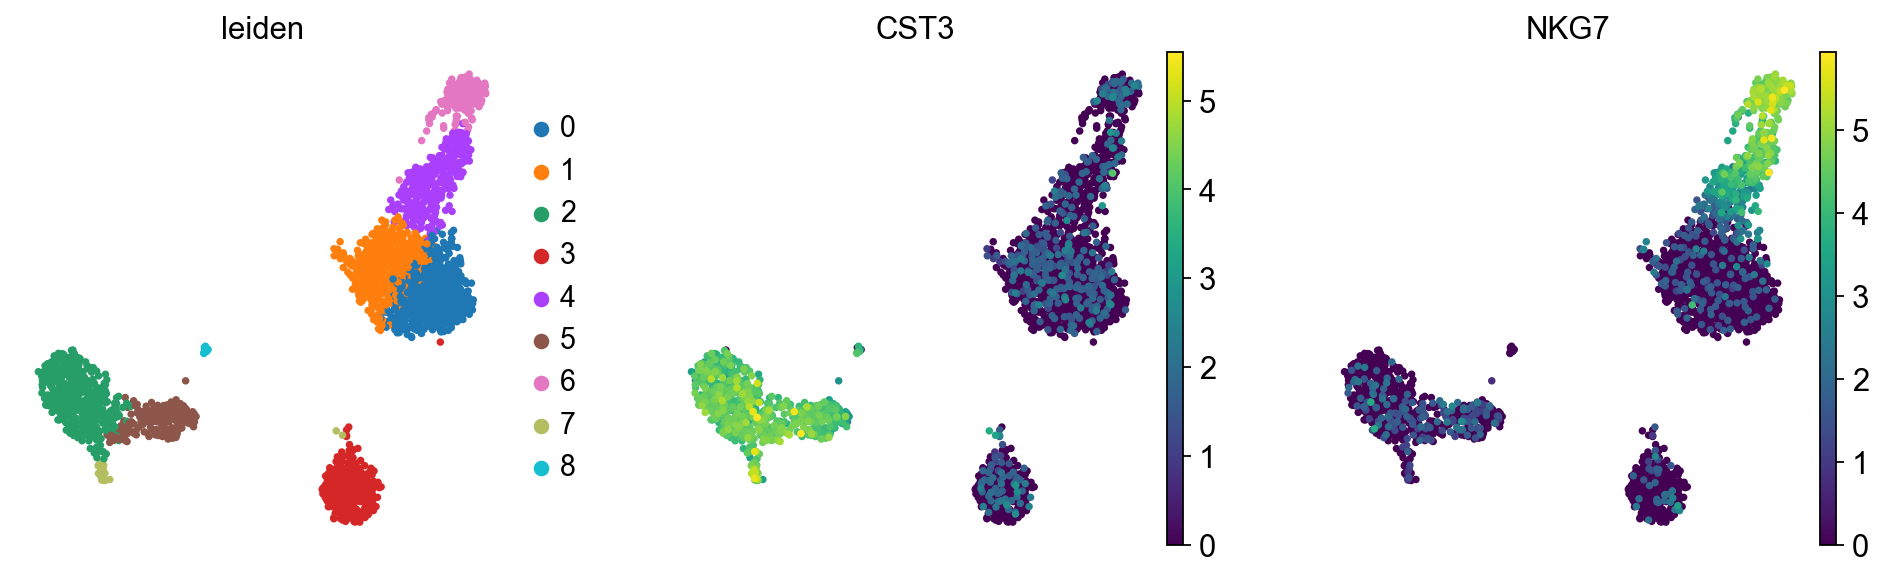

In [8]:
# Visualize the results
sc.pl.umap(adata_pbmc, color=['leiden', 'CST3', 'NKG7'], ncols=3)

## 4. The scverse Ecosystem

<img src="https://user-images.githubusercontent.com/8238804/236215054-96b20b86-4f15-4b89-8e54-ac556ba4aafb.svg" alt="scverse Logo" width="200"/>

The **scverse** (single-cell verse) is a community-driven ecosystem of interoperable Python tools for single-cell omics analysis. All tools in the scverse:

1. **Use AnnData** as the central data structure
2. **Follow common conventions** for function naming and data organization
3. **Are actively maintained** by the community
4. **Emphasize best practices** and reproducibility

### Core scverse Packages

| Package | Purpose | Key Features |
|---------|---------|-------------|
| **scanpy** | Core single-cell analysis | Preprocessing, clustering, visualization |
| **anndata** | Data structure | Efficient storage, manipulation |
| **scvi-tools** | Deep learning models | Dimensionality reduction, integration, imputation |
| **squidpy** | Spatial transcriptomics | Spatial analysis, image processing |
| **muon** | Multimodal omics | Multi-omics integration (RNA+ATAC, etc.) |
| **scirpy** | TCR/BCR analysis | Immune repertoire analysis |
| **cellrank** | Trajectory inference | Cell fate prediction, RNA velocity |
| **pertpy** | Perturbation analysis | CRISPR screens, drug responses |
| **palantir** | Differentiation analysis | Continuous pseudotime, branch probabilities, differentiation potential |

### Example: Using Multiple scverse Tools Together

One of the major advantages of the scverse is seamless integration between tools:

In [9]:
# Example workflow combining multiple tools (pseudo-code)
# 
# import scanpy as sc
# import scvi
# import cellrank as cr
#
# # 1. Preprocess with Scanpy
# sc.pp.filter_genes(adata, min_cells=3)
# sc.pp.normalize_total(adata)
#
# # 2. Integrate batches with scvi-tools
# scvi.model.SCVI.setup_anndata(adata, batch_key="batch")
# model = scvi.model.SCVI(adata)
# model.train()
# adata.obsm["X_scVI"] = model.get_latent_representation()
#
# # 3. Infer trajectories with CellRank
# cr.tl.terminal_states(adata, use_rep="X_scVI")
# cr.tl.lineages(adata)
#
# # 4. Visualize with Scanpy
# sc.pl.umap(adata, color="lineage_probability")

print("All these tools work on the same AnnData object!")

All these tools work on the same AnnData object!


**References**:
- [scverse.org](https://scverse.org/) - Central hub for all scverse projects
- [Single-cell best practices book](https://www.sc-best-practices.org/) - Community-driven guide

## 5. Standardization Efforts in Single-Cell Analysis

The scverse community has been a leader in promoting standardization across single-cell analysis. While these standards aren't enforced by the tools themselves, following them ensures your analyses are reproducible, shareable, and compatible with public databases.

### 1. Data Format Standards

**AnnData/HDF5 (.h5ad)**
- Language-agnostic format for storing single-cell data
- Efficient storage with compression and chunking
- **Reference**: [AnnData specification](https://anndata.readthedocs.io/)

**MuData (.h5mu)**
- Extension for multi-modal data (RNA + ATAC + Protein simultaneously)
- Maintains relationships between modalities
- **Reference**: [MuData documentation](https://mudata.readthedocs.io/)

**Zarr support**
- Cloud-native storage for massive datasets (millions of cells)
- Enables distributed computing and streaming
- **Reference**: [Zarr Python implementation](https://zarr.readthedocs.io/)

### 2. Analysis Best Practices

The **[Single-cell best practices book](https://www.sc-best-practices.org/)** is a community-curated resource providing:
- Evidence-based method recommendations (with benchmarks)
- Step-by-step tutorials with real datasets
- Critical discussion of method assumptions and limitations
- Updated regularly as new methods emerge

**Key chapters**:
- [Quality control](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html)
- [Integration](https://www.sc-best-practices.org/integration/integration.html)
- [Cell type annotation](https://www.sc-best-practices.org/cell_annotation/introduction.html)

### 3. Metadata and Ontology Standards

Public databases (CELLxGENE, Human Cell Atlas) require standardized metadata using controlled vocabularies:

**Cell Ontology (CL)**
- Standardized cell type identifiers (e.g., `CL:0000624` = "CD4-positive, alpha-beta T cell")
- Enables cross-study integration and querying
- **Reference**: [Cell Ontology Browser](https://www.ebi.ac.uk/ols/ontologies/cl)

**Other ontologies**:
- **UBERON**: Anatomical structures (tissues, organs)
- **MONDO**: Diseases and conditions
- **EFO**: Experimental factors and conditions

**Example AnnData annotations** (following [CELLxGENE schema](https://github.com/chanzuckerberg/single-cell-curation)):
```python
adata.obs['cell_type'] = 'CD4-positive, alpha-beta T cell'  # Human-readable
adata.obs['cell_type_ontology_term_id'] = 'CL:0000624'       # Machine-readable
adata.obs['tissue'] = 'blood'
adata.obs['tissue_ontology_term_id'] = 'UBERON:0000178'
```

**Note**: These annotations are **not automatically generated** by scverse tools—they're added manually or with specialized annotation tools when preparing data for public sharing.

### 4. Computational Reproducibility

**Automated provenance tracking**:
- Many scverse tools log parameters in `adata.uns`
- Processing steps are recorded automatically
- Enables recreation of analyses from saved objects

**Workflow integration**:
- Compatible with [Snakemake](https://snakemake.readthedocs.io/), [Nextflow](https://www.nextflow.io/)
- [Bento](https://www.bento.bio/) for standardized single-cell pipelines

**Version control**:
- Tools report their versions in analysis outputs
- Environment management with `conda`, `mamba`, or `uv`

### Example: Inspecting processing history

In [10]:
# After running the PBMC analysis above, we can inspect what was done
print("Processing steps recorded in adata.uns:")
for key in adata_pbmc.uns.keys():
    print(f"  - {key}")

# Example: PCA parameters
if 'pca' in adata_pbmc.uns:
    print("\nPCA parameters:")
    print(adata_pbmc.uns['pca'])

Processing steps recorded in adata.uns:
  - log1p
  - hvg
  - pca
  - neighbors
  - umap
  - leiden
  - leiden_colors

PCA parameters:
{'params': {'zero_center': True, 'use_highly_variable': True, 'mask_var': 'highly_variable'}, 'variance': array([48.01167  , 16.770506 , 11.562855 ,  5.290176 ,  3.5355566,
        3.0542777,  2.822488 ,  2.4822433,  1.906899 ,  1.6893631,
        1.5624762,  1.5320278,  1.4817858,  1.4236221,  1.4143902,
        1.3992627,  1.3893442,  1.3670135,  1.3506807,  1.3403671,
        1.3317338,  1.3036693,  1.2945684,  1.2844335,  1.2771425,
        1.2719426,  1.2597086,  1.2481277,  1.2419151,  1.2348046,
        1.2139055,  1.2056105,  1.1875662,  1.182448 ,  1.1755332,
        1.1702878,  1.1619296,  1.1596615,  1.1484265,  1.1354983,
        1.1249633,  1.1179279,  1.1164567,  1.104167 ,  1.0960928,
        1.0832611,  1.0773705,  1.0749716,  1.0724628,  1.0649828],
      dtype=float32), 'variance_ratio': array([0.10155563, 0.03547344, 0.02445807, 0.011

## 6. Python vs. R: Similarities, Contrasts, and Interoperability

### Similarities

| Aspect | Python (scverse) | R (Seurat/Bioconductor) |
|--------|------------------|-------------------------|
| Core philosophy | Object-oriented, centralized data | Object-oriented, centralized data |
| Workflow | QC → Normalize → HVG → PCA → Clustering | QC → Normalize → HVG → PCA → Clustering |
| Visualization | Matplotlib-based plotting | ggplot2-based plotting |
| Community | Active, open-source | Active, open-source |

### Key Differences

| Feature | Python | R |
|---------|--------|---|
| **Ecosystem** | scverse (unified) | Fragmented (Seurat, Bioconductor, etc.) |
| **Data structure** | AnnData (one standard) | Multiple (Seurat, SingleCellExperiment, CellDataSet) |
| **Primary library** | Scanpy | Seurat |
| **Deep learning** | Excellent (PyTorch, scvi-tools) | Limited |
| **Statistical modeling** | Good (statsmodels) | Excellent (native R stats) |
| **Scalability** | Excellent (sparse matrices, AnnData) | Good (with tricks) |
| **Integration methods** | Harmony, scVI, scANVI | Harmony, Seurat CCA/RPCA |

### Interoperability

You can easily convert between Python and R objects:

#### Python → R

In [11]:
# Save AnnData to h5ad format
# adata.write('my_analysis.h5ad')

# In R, load with Seurat:
# library(Seurat)
# library(SeuratDisk)
# Convert("my_analysis.h5ad", dest = "h5seurat", overwrite = TRUE)
# seurat_obj <- LoadH5Seurat("my_analysis.h5seurat")

print("AnnData objects can be converted to Seurat objects!")

AnnData objects can be converted to Seurat objects!


#### R → Python

```r
# In R, save Seurat object
library(SeuratDisk)
SaveH5Seurat(seurat_obj, filename = "seurat_obj.h5Seurat")
Convert("seurat_obj.h5Seurat", dest = "h5ad")
```

```python
# In Python, load as AnnData
import scanpy as sc
adata = sc.read_h5ad('seurat_obj.h5ad')
```

### Tools for Conversion

- **sceasy**: R package for easy conversion between formats
- **anndata2ri**: Direct Python-R communication via rpy2
- **zellkonverter**: Bioconductor package for AnnData ↔ SingleCellExperiment

### Direct R Integration with rpy2

You can run R code directly from Python using **rpy2**, which is useful when you need specific R packages not available in Python:

**Install rpy2**: Already included in Setup.md (`uv pip install rpy2`)

**Example: Using R's Seurat from Python**

**Using anndata2ri for direct AnnData ↔ R conversion**:

```python
from rpy2.robjects import conversion
import anndata2ri

# Set anndata2ri as default converter
conversion.set_conversion(anndata2ri.converter)

# Now AnnData objects are automatically converted
r.assign("sce", adata_pbmc)
r('library(scater); sce <- logNormCounts(sce)')
adata_from_r = r['sce']

# Reset to default when done
conversion.set_conversion(conversion.converter)
```

**Required R packages** (install once):
```r
# In R console:
install.packages("BiocManager")
BiocManager::install(c("SingleCellExperiment", "scater"))
```

**Advantages of rpy2**:
- No file I/O needed—direct memory sharing
- Can call R functions from Python and vice versa
- Useful for R-specific methods (complex stats, specialized Bioconductor packages)

**Limitations**:
- Requires R installed on your system
- R packages must be installed separately
- Debugging across languages can be tricky

**References**: 
- [rpy2 documentation](https://rpy2.github.io/)
- [anndata2ri documentation](https://icb-anndata2ri.readthedocs-hosted.com/)

In [13]:
import os
import anndata2ri
import rpy2.robjects as ro
from rpy2.robjects import conversion

# optionally specify path to your R executable:
# os.environ["R_HOME"] = "/opt/homebrew/opt/r/lib/R"

conversion.set_conversion(anndata2ri.converter)

# Send AnnData to R
ro.globalenv["adata"] = adata_pbmc

# Minimal R single-cell QC with scuttle; pick an existing assay
adata_with_r_qc = ro.r('''
suppressPackageStartupMessages({
  library(scuttle)
})

qc <- perCellQCMetrics(adata, exprs_values = "X")
colData(adata) <- cbind(colData(adata), qc)
metadata(adata) <- list() # remove none convertable metadata
adata
''')

print("✓ R scuttle QC added. New columns in .obs (head):")
adata_with_r_qc.obs.head()

/Users/dotto/.local/share/uv/python/cpython-3.11.11-macos-aarch64-none/lib/python3.11/functools.py:909: NotConvertedWarning: Conversion 'py2rpy' not defined for objects of type '<class 'NoneType'>'
  return dispatch(args[0].__class__)(*args, **kw)


✓ R scuttle QC added. New columns in .obs (head):


,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,sum,detected,total
AAACATACAACCAC-1,781,779,2419.0,73.0,3.017776,4,1605.823440,779,1605.823440
AAACATTGAGCTAC-1,1352,1352,4903.0,186.0,3.793596,3,2027.859402,1352,2027.859402
AAACATTGATCAGC-1,1131,1129,3147.0,28.0,0.889736,1,2040.169356,1129,2040.169356
AAACCGTGCTTCCG-1,960,960,2639.0,46.0,1.743085,2,1902.959676,960,1902.959676
AAACCGTGTATGCG-1,522,521,980.0,12.0,1.224490,6,1388.125345,521,1388.125345


## 7. Additional Resources and the scverse Community

### Official Documentation

- **scverse**: [https://scverse.org/](https://scverse.org/)
- **Scanpy**: [https://scanpy.readthedocs.io/](https://scanpy.readthedocs.io/)
- **AnnData**: [https://anndata.readthedocs.io/](https://anndata.readthedocs.io/)
- **Single-cell best practices**: [https://www.sc-best-practices.org/](https://www.sc-best-practices.org/)

### Tutorials and Learning Resources

- **Scanpy tutorials**: [https://scanpy-tutorials.readthedocs.io/](https://scanpy-tutorials.readthedocs.io/)
- **scverse tutorials**: [https://scverse.org/tutorials/](https://scverse.org/tutorials/)
- **Single-cell primers**: [https://github.com/settylab/single-cell-primers](https://github.com/settylab/single-cell-primers)

### Getting Help

- **Discourse forum**: [https://discourse.scverse.org/](https://discourse.scverse.org/)
- **GitHub issues**: Each tool has its own GitHub repo for bug reports
- **Social media**: #scverse, #scanpy (on Bluesky/Twitter/X)

### Contributing to scverse

The scverse is a community-driven project! You can contribute by:
- Reporting bugs and requesting features
- Contributing code to existing packages
- Writing documentation and tutorials
- Developing new scverse-compatible tools

## Summary

In this notebook, we've covered:

1. **AnnData**: The foundational data structure for Python single-cell analysis
2. **Scanpy**: The core analysis library with rich functionality
3. **scverse ecosystem**: A unified collection of interoperable tools
4. **Standardization efforts**: Best practices, data formats, and reproducibility
5. **Python vs. R**: Complementary ecosystems with good interoperability

### Next Steps

In the next notebook (`02_PBMC_RNA_Analysis.ipynb`), we'll apply these concepts to a real PBMC dataset, walking through a complete analysis pipeline with references to best practices and advanced techniques.

**Ready to analyze some real data? Let's move on to Notebook 2!**